In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# LOAD DATA
# -------------------------------
df = pd.read_csv('cleaned_ecommerce.csv')
df

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Customer_Value,Avg_Spend_Per_Item,Customer_Activity
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied,"(1000, 2000]",80.014286,Active
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral,"(500, 1000]",70.954545,Active
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,"(500, 1000]",56.750000,Warm
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied,"(1000, 2000]",77.910526,Active
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied,"(500, 1000]",55.415385,Warm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,446,Male,32,Miami,Silver,660.30,10,3.8,True,42,Unsatisfied,"(500, 1000]",66.030000,Warm
344,447,Female,36,Houston,Bronze,470.50,8,3.0,False,27,Neutral,"(0, 500]",58.812500,Active
345,448,Female,30,New York,Gold,1190.80,16,4.5,True,28,Satisfied,"(1000, 2000]",74.425000,Active
346,449,Male,34,Los Angeles,Silver,780.20,11,4.2,False,21,Neutral,"(500, 1000]",70.927273,Active


In [ ]:

# 1. HYPOTHESIS TESTING
print("1. HYPOTHESIS TESTING")
print("==============================")

# ---------------------------------
# CHI-SQUARE TEST
# ---------------------------------
# Question:
# Does Membership Type influence Satisfaction Level?

contingency_table = pd.crosstab(
    df['Membership Type'],
    df['Satisfaction Level']
)

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print("\nChi-Square Test Results")
print("------------------------")
print("Chi2 Statistic:", chi2)
print("P-value:", p_chi2)
print("Degrees of Freedom:", dof)
if p_chi2 < 0.05:
    print("Insight: Membership Type significantly affects Satisfaction Level.")
else:
    print("Insight: No statistically significant relationship detected.")


# ---------------------------------
# T-TEST
# ---------------------------------
# Compare spending between satisfied and unsatisfied users

satisfied = df[df['Satisfaction Level'] == 'Satisfied']['Total Spend']
unsatisfied = df[df['Satisfaction Level'] == 'Unsatisfied']['Total Spend']

t_stat, p_ttest = stats.ttest_ind(satisfied, unsatisfied, equal_var=False)

print("\nT-Test Results")
print("------------------------")
print("T-statistic:", t_stat)
print("P-value:", p_ttest)

if p_ttest < 0.05:
    print("Insight: Spending differs significantly between satisfied and unsatisfied customers.")
else:
    print("Insight: No significant spending difference found.")


1. HYPOTHESIS TESTING

Chi-Square Test Results
------------------------
Chi2 Statistic: 315.8033204939019
P-value: 4.219963613064734e-67
Degrees of Freedom: 4
Insight: Membership Type significantly affects Satisfaction Level.

T-Test Results
------------------------
T-statistic: 35.7997466772814
P-value: 5.319483692951711e-86
Insight: Spending differs significantly between satisfied and unsatisfied customers.



2. CORRELATION ANALYSIS

Correlation Matrix
                               Age  Days Since Last Purchase  Total Spend  \
Age                       1.000000                  0.170437    -0.676826   
Days Since Last Purchase  0.170437                  1.000000    -0.544679   
Total Spend              -0.676826                 -0.544679     1.000000   
Sat_Score                -0.463274                 -0.773735     0.797494   

                          Sat_Score  
Age                       -0.463274  
Days Since Last Purchase  -0.773735  
Total Spend                0.797494  
Sat_Score                  1.000000  


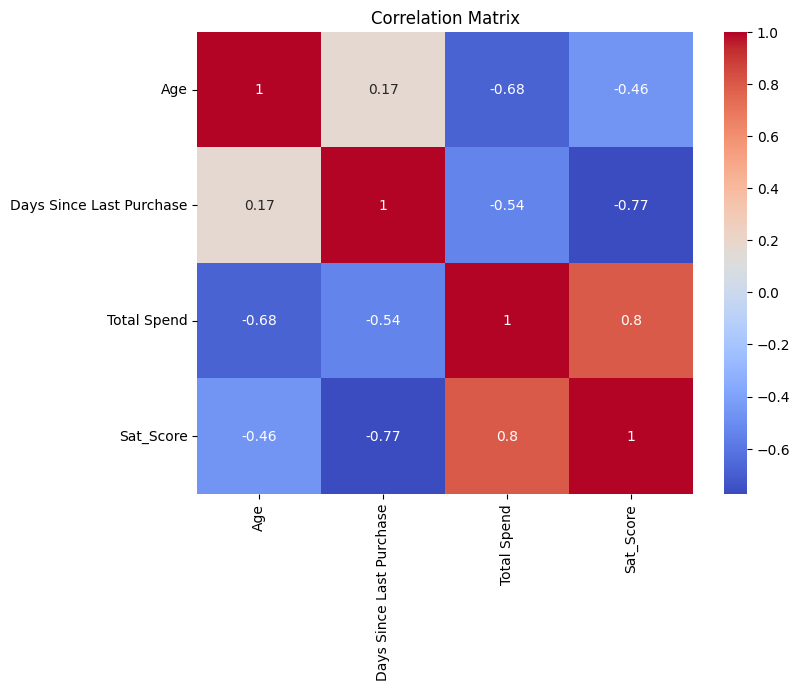

In [ ]:
# =========================================================
# 2. CORRELATION ANALYSIS
# =========================================================
print("2. CORRELATION ANALYSIS")
print("==============================")

# Map satisfaction levels to numeric
sat_map = {
    'Unsatisfied': 1,
    'Neutral': 2,
    'Satisfied': 3
}

df['Sat_Score'] = df['Satisfaction Level'].map(sat_map)

numeric_cols = [
    'Age',
    'Days Since Last Purchase',
    'Total Spend',
    'Sat_Score'
]

corr_matrix = df[numeric_cols].corr()

print("\nCorrelation Matrix")
print(corr_matrix)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:

# 3. REGRESSION ANALYSIS
# =========================================================
print("3. REGRESSION ANALYSIS")
print("==============================")

# Independent Variables
X = df[['Age', 'Days Since Last Purchase', 'Total Spend']]

# Add intercept
X = sm.add_constant(X)

# Dependent Variable
y = df['Sat_Score']

# Build model
model = sm.OLS(y, X).fit()

print(model.summary())

# Key Metrics
print("\nRegression Insights")
print("------------------------")
print("R-squared:", model.rsquared)
print("Adjusted R-squared:", model.rsquared_adj)

# Interpretation of coefficients
coefficients = model.params

for variable, coef in coefficients.items():
    print(f"{variable}: {coef:.4f}")


3. REGRESSION ANALYSIS
                            OLS Regression Results                            
Dep. Variable:              Sat_Score   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.799
Method:                 Least Squares   F-statistic:                     460.1
Date:                Mon, 04 May 2026   Prob (F-statistic):          5.20e-120
Time:                        09:53:54   Log-Likelihood:                -149.22
No. Observations:                 348   AIC:                             306.4
Df Residuals:                     344   BIC:                             321.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
c

4. TREND ANALYSIS


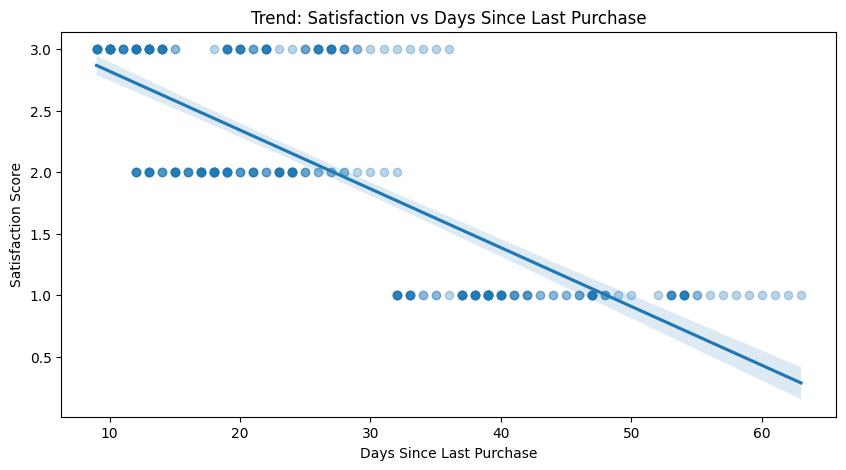


Trend Correlation
------------------------
Correlation: -0.7737346014118135
P-value: 1.4103828816615848e-70
Insight: Customer satisfaction significantly decreases as recency increases.


In [ ]:

# 4. TREND / TIME-BASED ANALYSIS
print("4. TREND ANALYSIS")
print("==============================")

plt.figure(figsize=(10,5))

sns.regplot(
    x='Days Since Last Purchase',
    y='Sat_Score',
    data=df,
    scatter_kws={'alpha':0.3}
)

plt.title('Trend: Satisfaction vs Days Since Last Purchase')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Satisfaction Score')

plt.show()

# Correlation significance
corr, p_corr = stats.pearsonr(
    df['Days Since Last Purchase'],
    df['Sat_Score']
)

print("\nTrend Correlation")
print("------------------------")
print("Correlation:", corr)
print("P-value:", p_corr)

if p_corr < 0.05:
    print("Insight: Customer satisfaction significantly decreases as recency increases.")
else:
    print("Insight: No significant recency trend found.")


5. UNCERTAINTY & VARIABILITY
Mean Satisfaction: 2.026
Standard Deviation: 0.833
95% Confidence Interval: (np.float64(1.9380387513804174), np.float64(2.1136853865506176))


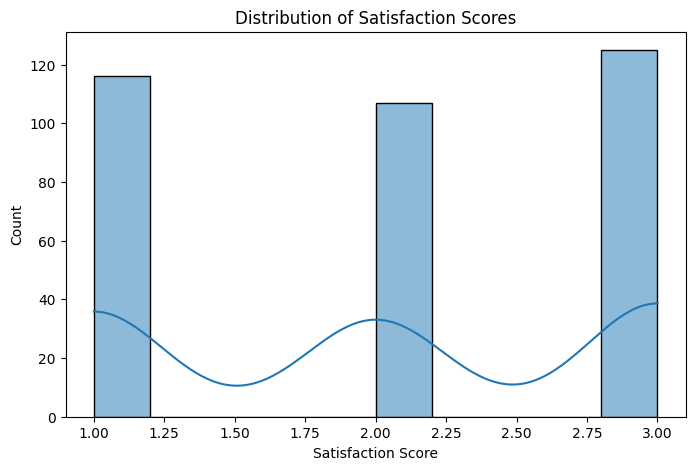

In [ ]:
# =========================================================
# 5. UNCERTAINTY & VARIABILITY
# =========================================================
print("\n==============================")
print("5. UNCERTAINTY & VARIABILITY")
print("==============================")

mean_sat = df['Sat_Score'].mean()
std_sat = df['Sat_Score'].std()

conf_int = stats.t.interval(
    confidence=0.95,
    df=len(df)-1,
    loc=mean_sat,
    scale=stats.sem(df['Sat_Score'])
)

print("Mean Satisfaction:", round(mean_sat, 3))
print("Standard Deviation:", round(std_sat, 3))
print("95% Confidence Interval:", conf_int)

# Distribution Plot
plt.figure(figsize=(8,5))

sns.histplot(df['Sat_Score'], kde=True)

plt.title("Distribution of Satisfaction Scores")
plt.xlabel("Satisfaction Score")

plt.show()
